In [1]:
import pandas as pd
import numpy as np
import nibabel as nib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

(np.float64(-0.5), np.float64(255.5), np.float64(0.5), np.float64(-0.5))

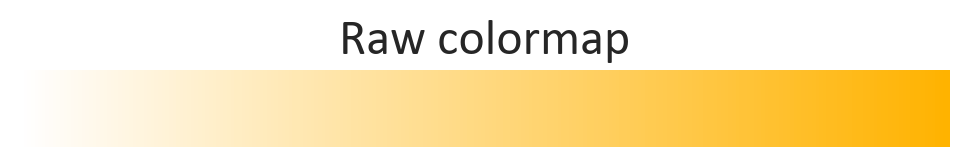

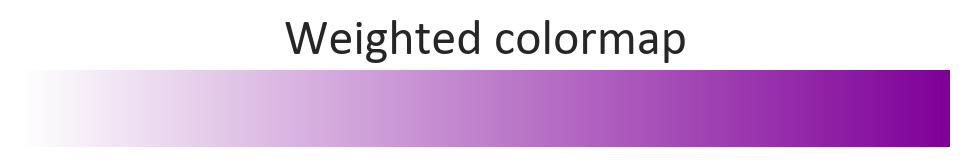

In [2]:
# ── Global visualisation configuration ──────────────────────────────────────

# 1.  General Matplotlib defaults
# ── Global visualisation configuration ──────────────────────────────────────
import matplotlib as mpl
import seaborn as sns

# Add font family to the rcParams (from tff file)
from matplotlib import font_manager

font_path = "/home/groot/.fonts/calibri-regular.ttf"
font_manager.fontManager.addfont(font_path)


mpl.rcParams.update(
    {
        # ── Canvas size & resolution ───────────────────────────────────────────
        # Default figure size: 12×8 inches  →  4800×3200 px when exported at 400 dpi
        "figure.figsize": (12, 8),
        "figure.dpi": 200,  # crisp in-notebook / retina preview
        "savefig.dpi": 400,  # print-quality PNG/PDF
        # ── Fonts ──────────────────────────────────────────────────────────────
        "font.family": "Calibri",
        # "font.sans-serif": ["Roboto", "DejaVu Sans", "Arial"],
        "font.sans-serif": ["Calibri", "DejaVu Sans", "Arial"],
        "axes.titlesize": 24,
        # "axes.titleweight": "bold",
        "axes.labelsize": 24,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 20,
        # ── Axis & spine aesthetics ────────────────────────────────────────────
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": True,
        "axes.spines.bottom": True,
        "axes.linewidth": 1,
        "axes.grid": True,
        "grid.color": "#E6E6E6",
        "grid.linewidth": 0.4,
        "grid.alpha": 0.8,
        # ── Colour cycle (colour-blind-safe) ───────────────────────────────────
        "axes.prop_cycle": mpl.cycler(color=sns.color_palette("Set2")),
        # ── Figure background ─────────────────────────────────────────────────
        "figure.facecolor": "white",
    }
)

# Seaborn theme inherits the rcParams above
sns.set_theme(context="talk", style="whitegrid", palette="Set2")


# 2.  Seaborn theme (inherits Matplotlib rcParams)
sns.set_theme(
    context="talk",  # slightly larger fonts for presentations / papers
    style="whitegrid",  # grid only on y-axis (good for histograms)
    palette="Set2",  # matches the rcParams colour cycle
)


# 3.  Helper function for consistent figure export
def savefig_nice(fig, filename, *, tight=True, transparent=True, dpi=300, **savefig_kwargs):
    """Save figure with tight layout and correct DPI."""
    if tight:
        fig.tight_layout()
    fig.savefig(filename, dpi=dpi, bbox_inches="tight", transparent=transparent, **savefig_kwargs)

mpl.rcParams["font.family"] = "Calibri"  # or any other font you want

# 4.  Colour constants for this project (optional convenience)
# COL_RAW = "#1f77b4"  # e.g. unweighted sample
COL_RAW = "#ffb300"
# COL_WEIGHTED = "#d62728"  # weighted sample
COL_WEIGHTED = "#7F0099CE"  # weighted sample
COL_REF = "0.25"  # census reference (neutral grey)
COL_CENSUS = "#A5A5A5"

# generate colormaps from white to colour
COL_WHITE = "white"
COL_RAW_RGB = mpl.colors.to_rgb(COL_RAW)
COL_WEIGHTED_RGB = mpl.colors.to_rgb(COL_WEIGHTED)
CMAP_RAW = mpl.colors.LinearSegmentedColormap.from_list("raw", [COL_WHITE, COL_RAW_RGB], N=256)
CMAP_WEIGHTED = mpl.colors.LinearSegmentedColormap.from_list(
    "weighted", [COL_WHITE, COL_WEIGHTED_RGB], N=256
)
# visualize the colormaps
# if __name__ == "__main__":
fig, ax = plt.subplots(figsize=(6, 0.5))
ax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=CMAP_RAW)
ax.set_title("Raw colormap")
ax.axis("off")
# savefig_nice(fig, "colormap_raw.png")

fig, ax = plt.subplots(figsize=(6, 0.5))
ax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=CMAP_WEIGHTED)
ax.set_title("Weighted colormap")
ax.axis("off")
# savefig_nice(fig, "colormap_weighted.png")

In [3]:
ATLAS = "schaefer2018tian2020_400_7"
region_col = "index"
# Load important files
DATA_DIR = Path("/media/groot/Minerva/phd/neuroaging/data")

# Output directory for figures
OUTPUT_DIR = Path("/media/groot/Minerva/phd/neuroaging/figures/revision/fig1")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load the data
parcels = pd.read_csv(DATA_DIR / "external" / "atlases" / ATLAS / "parcels.csv", index_col=0)
nifti = DATA_DIR / "external" / "atlases" / ATLAS / "atlas.nii.gz"
nifti_matlab = DATA_DIR / "external" / "atlases" / ATLAS / "atlas_matlab.nii"

In [4]:
bad_subjects = ["IN120120"]

In [5]:
metric = ["gm_vol", "adc", "fa", "ad", "rd"]
distribution_metric = "qfmean"
if isinstance(metric, list):
    data_dict = {}
    for m in metric:
        data = pd.read_csv(DATA_DIR / "processed" / f"{m}.csv", index_col=0)
        data["subject_code"] = data["subject_code"].astype(str).apply(lambda x: x.replace(" ", "").replace(".", "").replace("-", "").replace("_", "")).astype(str).str.zfill(4)
        data = (
            data
            .reset_index(drop=True)
            .drop_duplicates(subset=["subject_code", region_col], keep="last")
        )
        data_dict[m] = data[~data["subject_code"].isin(bad_subjects)]
else:
    data = pd.read_csv(DATA_DIR / "processed" / f"{metric}.csv", index_col=0)
    data["subject_code"] = data["subject_code"].astype(str).apply(lambda x: x.replace(" ", "").replace(".", "").replace("-", "").replace("_", "")).astype(str).str.zfill(4)
    data = (
        data
        .reset_index(drop=True)
        .drop_duplicates(subset=["subject_code", region_col], keep="last")
    )
    data_dict = {metric: data[~data["subject_code"].isin(bad_subjects)]}

/tmp/ipykernel_2453039/781979806.py:6: DtypeWarning: Columns (1,7,61,67,71,72,73,74,75,77,78,79,80,85,86,87,88,89,90,92,106,108,109,114,115,116,117,118,125,126,127) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(DATA_DIR / "processed" / f"{m}.csv", index_col=0)
/tmp/ipykernel_2453039/781979806.py:6: DtypeWarning: Columns (16,22,23,26,32,36,37,38,39,40,42,43,44,45,50,51,52,53,54,55,57,71,73,74,79,80,81,82,89,90,91,101) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(DATA_DIR / "processed" / f"{m}.csv", index_col=0)
/tmp/ipykernel_2453039/781979806.py:6: DtypeWarning: Columns (16,22,23,26,32,36,37,38,39,40,42,43,44,45,50,51,52,53,54,55,57,71,73,74,79,80,81,82,89,90,91,101) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(DATA_DIR / "processed" / f"{m}.csv", index_col=0)
/tmp/ipykernel_2453039/781979806.py:6: DtypeWarning: Columns (16,22,23,26,32,36,

In [6]:
if isinstance(metric, list):
    data_global_dict = {}
    for m in metric:
        data = data_dict[m]
        if m == "gm_vol":
            data_global = data.drop_duplicates(subset=["subject_code"], keep="first")
            # data_global = data.drop_duplicates(subset=["session_id"], keep="first")
        else:
            data_global = (
                data.groupby("subject_code")
                .agg({distribution_metric: "mean", "sex": "first", "age_at_scan": "first"}) 
                .reset_index()
            )
        data_global_dict[m] = data_global.rename(columns={"total_gm_volume":distribution_metric})
else:
    if metric == "gm_vol":
        data_global = data.drop_duplicates(subset=["subject_code"], keep="first")
        # data_global = data.drop_duplicates(subset=["session_id"], keep="first")
    else:
        data_global = (
            data.groupby("subject_code")
            .agg({distribution_metric: "mean", "sex": "first", "age_at_scan": "first"})
            .reset_index()
        )
        # data_global = (
        #     data.groupby("session_id")
        #     .agg({distribution_metric: "mean", "sex": "first", "age_at_scan": "first"})
        #     .reset_index()
        # )

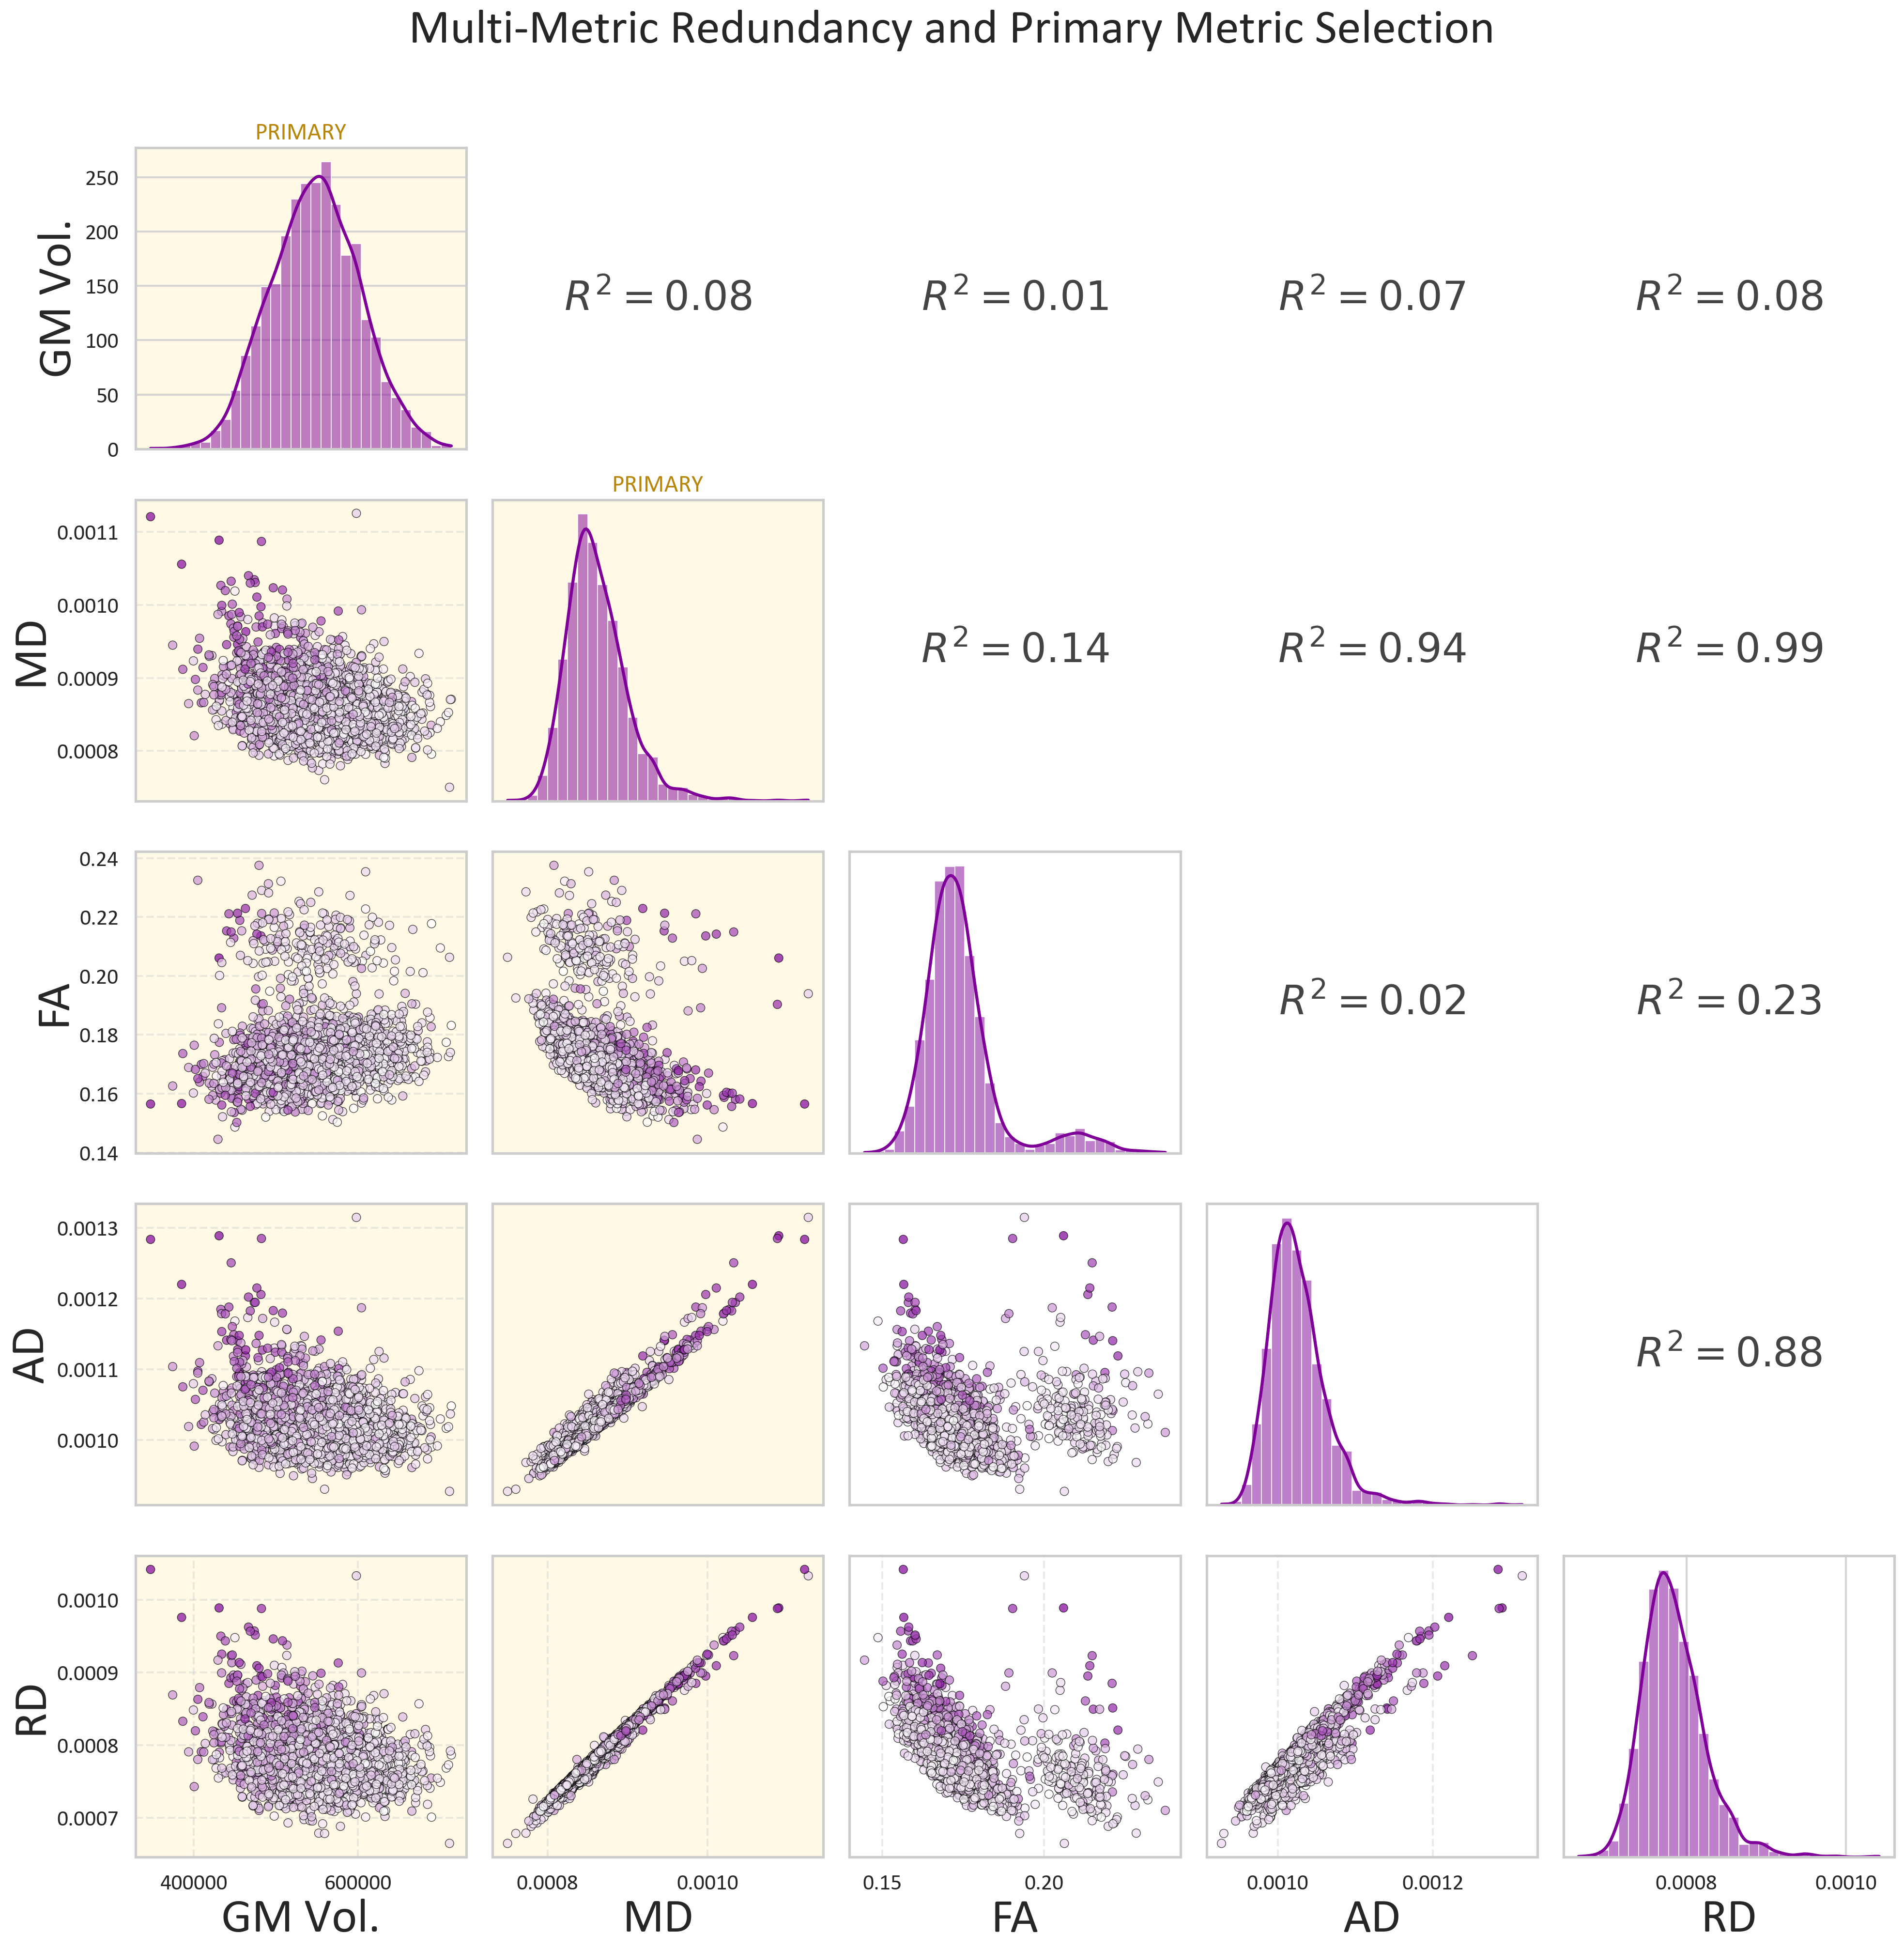

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# 1. Setup Labels
metric_labels = [m.replace("adc", "md").upper() if m != "gm_vol" else "GM Vol." for m in metric]
n_metrics = len(metric)

fig, axes = plt.subplots(n_metrics, n_metrics, figsize=(4 * n_metrics, 4 * n_metrics))

for i in range(n_metrics):
    for j in range(n_metrics):
        ax = axes[j, i]
        m1, m2 = metric[i], metric[j]
        
        # --- HIGHLIGHT LOGIC: Target first two columns (GM Vol and MD) ---
        is_highlighted = i < 2 
        if is_highlighted:
            ax.set_facecolor('#fff9e6') # Very light yellow/gold to highlight
        else:
            ax.set_facecolor('white')

        # --- DIAGONAL: Distributions ---
        if i == j:
            sns.histplot(data=data_global_dict[m1], x=distribution_metric, 
                         bins=30, kde=True, ax=ax, color=COL_WEIGHTED)
            if is_highlighted:
                ax.set_title("PRIMARY", fontsize=18, fontweight='bold', color='darkgoldenrod')

        # --- LOWER TRIANGLE: Scatters ---
        elif j > i:
            merged = pd.merge(data_global_dict[m1], data_global_dict[m2], on="subject_code")
            sns.scatterplot(data=merged, x=f"{distribution_metric}_x", y=f"{distribution_metric}_y",
                            hue=f"age_at_scan_x", ax=ax, palette=CMAP_WEIGHTED, 
                            edgecolor="black", alpha=0.7, s=40, legend=False)
            ax.grid(True, linestyle='--', alpha=0.4)

        # --- UPPER TRIANGLE: R² Annotations ---
        else:
            merged = pd.merge(data_global_dict[m1], data_global_dict[m2], on="subject_code")
            r, _ = pearsonr(merged[f"{distribution_metric}_x"], merged[f"{distribution_metric}_y"])
            r_sq = r**2
            ax.text(0.5, 0.5, f"$R^2 = {r_sq:.2f}$", ha='center', va='center', 
                    fontsize=30, weight='bold', color='#444444')
            ax.axis('off')
            continue

        # --- TICK MANAGEMENT (Clean standard) ---
        # Keep Y-labels only on the leftmost edge
        if i == 0:
            ax.set_ylabel(metric_labels[j], fontsize=36, fontweight='bold')
        else:
            ax.set_ylabel("")
            ax.set_yticks([]) # Remove ticks from non-leftmost columns

        # Keep X-labels only on the bottom row
        if j == n_metrics - 1:
            ax.set_xlabel(metric_labels[i], fontsize=36, fontweight='bold')
        else:
            ax.set_xlabel("")
            ax.set_xticks([]) # Remove ticks from non-bottom rows

# Add a bold title to the figure
plt.suptitle("Multi-Metric Redundancy and Primary Metric Selection", fontsize=36, y=1.01)
plt.tight_layout()
# plt.show()
savefig_nice(fig, OUTPUT_DIR / "supp_fig_metric_correlations_matrix.png", dpi=400, transparent=False)

In [8]:
OUTPUT_DIR

PosixPath('/media/groot/Minerva/phd/neuroaging/figures/revision/fig1')

In [9]:
sns.heatmap(
    p_df.astype(float),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    # vmin=-1,
    # vmax=1,
)

NameError: name 'p_df' is not defined